# The Continuous Thought Machine with `CTMAttention` — MNIST

This notebook trains a **minimal CTM variant** on MNIST whose only computational module is a single `CTMAttention` block.

Compared to `01_mnist.ipynb`, this version drops:
- the **CNN backbone** (input is tokenised by a plain linear patch embedding),
- the **`nn.MultiheadAttention`** block,
- the separate **synapse / trace_processor** "Core CTM Modules".

All CTM machinery — Neuron-Level Models with private per-neuron traces, exponentially-decayed pairwise **Synchronization**, and the action/output sync streams — lives inside `CTMAttention`. Its Q, K, V *and* output projections are NLM + Sync.

Pipeline per outer tick:

```
tokens = patch_embed(x) + pos_embed                # one-time tokenisation
out, attn_weights, state = ctm_attention(t, t, t, state)
logits = head(out.mean(dim=1))                     # per-tick prediction
```


### Imports

In [1]:
import os
import sys
import math
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from scipy.special import softmax
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import seaborn as sns
import imageio
import mediapy

# Make repository root importable when running this notebook from `examples/`
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), os.pardir)))
from models.ctm_attention import CTMAttention


### Seeding

In [2]:
def set_seed(seed=42, deterministic=True):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cudnn.benchmark = False

set_seed(42)


### Helper: normalized entropy (used for certainty)

In [3]:
def compute_normalized_entropy(logits, reduction='mean'):
    preds = F.softmax(logits, dim=-1)
    log_preds = torch.log_softmax(logits, dim=-1)
    entropy = -torch.sum(preds * log_preds, dim=-1)
    num_classes = preds.shape[-1]
    max_entropy = torch.log(torch.tensor(num_classes, dtype=torch.float32, device=logits.device))
    normalized_entropy = entropy / max_entropy
    if len(logits.shape) > 2 and reduction == 'mean':
        normalized_entropy = normalized_entropy.flatten(1).mean(-1)
    return normalized_entropy


## Model

The `ContinuousThoughtMachine` defined here is intentionally tiny:

- **Tokenisation** — `nn.Linear(patch_size**2, embed_dim)` on `4x4` MNIST patches → `7x7 = 49` tokens. Plus a learnable positional embedding. No convolutions.
- **Single `CTMAttention`** — replaces the original `kv_proj`, `q_proj`, `nn.MultiheadAttention`, `synapses`, and `trace_processor` all at once. Used as self-attention across patch tokens.
- **Head** — `nn.Linear(embed_dim, 10)` applied to a mean-pooled CTMAttention output.

`CTMAttention` carries its own state (Q/K/V/O traces + decayed sync recurrence) forward across outer ticks — we pass `state` in and out of the call.

In [4]:
class ContinuousThoughtMachine(nn.Module):
    def __init__(self,
                 iterations=15,
                 image_size=28,
                 patch_size=4,
                 embed_dim=64,
                 num_heads=1,
                 memory_length=10,
                 d_model_qkv=64,
                 d_model_o=64,
                 n_synch_qkv=16,
                 n_synch_o=16,
                 out_dims=10,
                 dropout=0.0):
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError('image_size must be divisible by patch_size')

        self.iterations = iterations
        self.patch_size = patch_size
        self.out_dims = out_dims

        n_patches = (image_size // patch_size) ** 2
        patch_dim = patch_size * patch_size  # MNIST is single-channel

        # --- Tokenisation: no CNN backbone, just a linear patch embedding + pos emb ---
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # --- The one and only CTMAttention block (replaces all Core CTM Modules) ---
        self.ctm_attention = CTMAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            memory_length=memory_length,
            d_model_qkv=d_model_qkv,
            d_model_o=d_model_o,
            n_synch_qkv=n_synch_qkv,
            n_synch_o=n_synch_o,
            dropout=dropout,
        )

        # --- Classification head ---
        self.head = nn.Linear(embed_dim, out_dims)

    def tokenize(self, x):
        '''(B, 1, H, W) -> (B, n_patches, embed_dim) via reshape + linear.'''
        B, _, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)             # (B, 1, H/p, W/p, p, p)
        x = x.permute(0, 2, 3, 1, 4, 5).contiguous().view(B, -1, p * p)
        return self.patch_embed(x) + self.pos_embed

    def forward(self, x, track=False):
        B = x.size(0)
        device = x.device
        tokens = self.tokenize(x)

        predictions = torch.empty(B, self.out_dims, self.iterations, device=device, dtype=x.dtype)
        certainties = torch.empty(B, 2, self.iterations, device=device, dtype=x.dtype)

        attention_tensors = []           # list of live torch tensors (for Grad-CAM)
        token_activations_tracking = []  # numpy (no grad needed)
        sync_o_tracking = []             # numpy (no grad needed)

        state = None
        for stepi in range(self.iterations):
            # Self-attention over the patch tokens. State threads NLM traces and
            # the sync recurrence forward across outer ticks.
            out, attn_weights, state = self.ctm_attention(tokens, tokens, tokens, state=state)

            # Per-tick prediction: mean-pool over patches, then linear head.
            pooled = out.mean(dim=1)
            logits = self.head(pooled)
            ne = compute_normalized_entropy(logits)
            certainty = torch.stack((ne, 1 - ne), -1)

            predictions[..., stepi] = logits
            certainties[..., stepi] = certainty

            if track:
                # Keep attn_weights as a live torch tensor so the caller can
                # backprop through it for Grad-CAM-style saliency. Everything
                # else can be detached / numpyified immediately.
                attention_tensors.append(attn_weights)
                token_activations_tracking.append(out.detach().cpu().numpy())
                sync_o_tracking.append(state['decay_alpha_o'].mean(dim=1).detach().cpu().numpy())

        if track:
            return (predictions, certainties,
                    attention_tensors,                         # list[Tensor]
                    np.array(token_activations_tracking),
                    np.array(sync_o_tracking))
        return predictions, certainties


## Certainty-based loss

Same formulation as `01_mnist.ipynb`: average the CE losses at the tick with the *lowest* loss and the tick of *highest* certainty.

In [5]:
def get_loss(predictions, certainties, targets, use_most_certain=True):
    losses = nn.CrossEntropyLoss(reduction='none')(
        predictions,
        torch.repeat_interleave(targets.unsqueeze(-1), predictions.size(-1), -1))
    loss_index_1 = losses.argmin(dim=1)
    loss_index_2 = certainties[:, 1].argmax(-1)
    if not use_most_certain:
        loss_index_2[:] = -1
    batch_indexer = torch.arange(predictions.size(0), device=predictions.device)
    loss = (losses[batch_indexer, loss_index_1].mean()
            + losses[batch_indexer, loss_index_2].mean()) / 2
    return loss, loss_index_2


def calculate_accuracy(predictions, targets, where_most_certain):
    B = predictions.size(0)
    device = predictions.device
    idx = predictions.argmax(1)[torch.arange(B, device=device), where_most_certain]
    return (targets.detach().cpu().numpy() == idx.detach().cpu().numpy()).mean()


## Data

In [6]:
def prepare_data(batch_size=256, data_root='./data', num_workers=1):
    transform = transforms.Compose([
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ])
    train_data = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
    test_data = datasets.MNIST(root=data_root, train=False, download=True, transform=test_transform)
    trainloader = torch.utils.data.DataLoader(
        train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True)
    testloader = torch.utils.data.DataLoader(
        test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return trainloader, testloader


## Live training curves

In [7]:
def update_training_curve_plot(fig, ax1, ax2, train_losses, test_losses, train_accuracies, test_accuracies, steps):
    clear_output(wait=True)

    ax1.clear()
    ax1.plot(range(len(train_losses)), train_losses, 'b-', alpha=0.7, label=f'Train Loss: {train_losses[-1]:.3f}')
    ax1.plot(steps, test_losses, 'r-', marker='o', label=f'Test Loss: {test_losses[-1]:.3f}')
    ax1.set_title('Loss'); ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.clear()
    ax2.plot(range(len(train_accuracies)), train_accuracies, 'b-', alpha=0.7, label=f'Train Accuracy: {train_accuracies[-1]:.3f}')
    ax2.plot(steps, test_accuracies, 'r-', marker='o', label=f'Test Accuracy: {test_accuracies[-1]:.3f}')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Step'); ax2.set_ylabel('Accuracy')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    display(fig)


## Training loop

In [8]:
def train(model, trainloader, testloader, iterations, test_every, device, lr=5e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-8)
    iterator = iter(trainloader)
    model.train()

    train_losses, test_losses, train_accuracies, test_accuracies, steps = [], [], [], [], []
    plt.ion()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    test_loss = float('nan')
    test_accuracy = float('nan')
    with tqdm(total=iterations, dynamic_ncols=True) as pbar:
        for stepi in range(iterations):
            try:
                inputs, targets = next(iterator)
            except StopIteration:
                iterator = iter(trainloader)
                inputs, targets = next(iterator)
            inputs, targets = inputs.to(device), targets.to(device)

            predictions, certainties = model(inputs)
            train_loss, where_most_certain = get_loss(predictions, certainties, targets)
            train_accuracy = calculate_accuracy(predictions, targets, where_most_certain)

            train_losses.append(train_loss.item())
            train_accuracies.append(train_accuracy)

            optimizer.zero_grad()
            train_loss.backward()
            optimizer.step()

            if stepi % test_every == 0 or stepi == iterations - 1:
                model.eval()
                with torch.inference_mode():
                    all_p, all_t, all_w, all_l = [], [], [], []
                    for inp, tgt in testloader:
                        inp, tgt = inp.to(device), tgt.to(device)
                        p, c = model(inp)
                        l, w = get_loss(p, c, tgt)
                        all_p.append(p); all_t.append(tgt); all_w.append(w)
                        all_l.append(l.item())
                    all_p = torch.cat(all_p, dim=0)
                    all_t = torch.cat(all_t, dim=0)
                    all_w = torch.cat(all_w, dim=0)
                    test_accuracy = calculate_accuracy(all_p, all_t, all_w)
                    test_loss = sum(all_l) / len(all_l)
                    test_losses.append(test_loss)
                    test_accuracies.append(test_accuracy)
                    steps.append(stepi)
                model.train()

            if stepi % 10 == 0 or stepi == iterations - 1:
                update_training_curve_plot(fig, ax1, ax2, train_losses, test_losses,
                                           train_accuracies, test_accuracies, steps)

            pbar.set_description(
                f'TrL {train_loss:.3f} TrA {train_accuracy:.3f} TeL {test_loss:.3f} TeA {test_accuracy:.3f}')
            pbar.update(1)

    plt.ioff()
    plt.close(fig)
    return model


## Instantiate the model

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

trainloader, testloader = prepare_data()

model = ContinuousThoughtMachine(
    iterations=15,
    patch_size=4,
    embed_dim=64,
    num_heads=1,
    memory_length=10,
    d_model_qkv=64,
    d_model_o=64,
    n_synch_qkv=16,
    n_synch_o=16,
    out_dims=10,
    dropout=0.0,
).to(device)


def clamp_decay_params(module, _input):
    '''Match the decay-parameter clamp from 01_mnist.ipynb, applied to all four CTMAttention pools.'''
    with torch.no_grad():
        for name in ('decay_params_q', 'decay_params_k', 'decay_params_v', 'decay_params_o'):
            getattr(module.ctm_attention, name).data.clamp_(0, 15)


model.register_forward_pre_hook(clamp_decay_params)

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')


Model parameters: 65,326


### Train

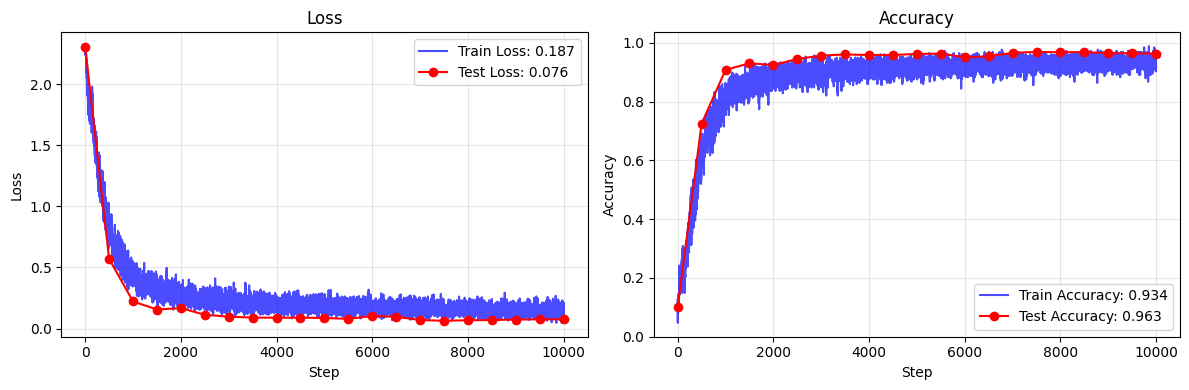

TrL 0.187 TrA 0.934 TeL 0.076 TeA 0.963: 100%|██████████| 10000/10000 [58:12<00:00,  2.86it/s]


In [10]:
model = train(model, trainloader, testloader, iterations=10000, test_every=500, device=device)


## Visualizing CTM Dynamics

The visualization shows what happens *inside* one outer tick of `CTMAttention`:

- **Input image** (top left).
- **Attention saliency** — *not* the raw mean of attention weights (that turned out to peak at the 4 corners, the classic *attention-sink* artifact). Instead we compute a **Grad-CAM-style saliency**:

  $$
  \mathrm{saliency}[t, k] \;=\; \sum_{q,\,h}\; \mathrm{ReLU}\!\left(A^{(h)}_t[q, k]\right)\;\cdot\;\mathrm{ReLU}\!\left(\frac{\partial\, \mathrm{logit}_y}{\partial\, A^{(h)}_t[q, k]}\right)
  $$

  where $y$ is the model's predicted class at tick $t$ and $A_t$ is the attention matrix at tick $t$. The two ReLUs keep only $(query,\,key)$ pairs the model both attends to *and* uses positively for that tick's prediction; background-query "dumps" into corners drop out automatically because their gradient is near zero.

- **Probabilities** — softmax over the per-tick logits.
- **Certainty** — `1 - normalized_entropy` plotted across all internal ticks.
- **Neuron traces** — 16 dimensions of the post-attention output (token-mean of `CTMAttention`'s output, i.e. a slice of the O-pool synchronization projection) plotted across ticks.

Saliency is computed by running a normal (non-`inference_mode`) forward and calling `torch.autograd.grad` on each tick's logit w.r.t. that tick's attention tensor.

In [11]:
def make_gif(predictions, certainties, targets, token_activations, heatmap,
             inputs_to_model, filename):
    '''
    heatmap: (T, B, H, W) ndarray of per-tick saliency maps to overlay
             (already aggregated and upsampled to the input image resolution).
    '''
    T = heatmap.shape[0]

    # Per-step "neuron" activations: mean over tokens of the CTMAttention output -> (T, B, embed_dim)
    neuron_acts = torch.tensor(token_activations, dtype=torch.float32).mean(dim=2).numpy()

    batch_index = 6
    n_neurons_to_visualise = 16
    figscale = 0.28
    n_steps = T
    heCTMap_cmap = sns.color_palette('viridis', as_cmap=True)
    frames = []

    these_inputs = inputs_to_model[batch_index, :, :, :]
    these_heatmaps = heatmap[:, batch_index, :, :]
    these_predictions = predictions[batch_index, :, :]
    these_certainties = certainties[batch_index, :, :]
    this_target = targets[batch_index]
    these_neuron_acts = neuron_acts[:, batch_index, :n_neurons_to_visualise]
    class_labels = [str(i) for i in range(these_predictions.shape[0])]

    mosaic = (
        [['img_data','img_data','attention','attention','probs','probs','probs','probs'] for _ in range(2)] +
        [['img_data','img_data','attention','attention','probs','probs','probs','probs'] for _ in range(2)] +
        [['certainty'] * 8] +
        [[f'trace_{ti}'] * 8 for ti in range(n_neurons_to_visualise)]
    )

    for stepi in tqdm(range(n_steps), desc='Frames'):
        fig_gif, axes_gif = plt.subplot_mosaic(mosaic=mosaic, figsize=(31*figscale*8/4, 76*figscale))

        # Probabilities
        probs = softmax(these_predictions[:, stepi])
        colors = [('g' if i == this_target else 'b') for i in range(len(probs))]
        axes_gif['probs'].bar(np.arange(len(probs)), probs, color=colors, width=0.9, alpha=0.5)
        axes_gif['probs'].set_title('Probabilities')
        axes_gif['probs'].set_xticks(np.arange(len(probs)))
        axes_gif['probs'].set_xticklabels(class_labels, fontsize=20)
        axes_gif['probs'].set_yticks([])
        axes_gif['probs'].set_ylim([0, 1])
        for spine in axes_gif['probs'].spines.values():
            spine.set_visible(False)

        # Certainty
        axes_gif['certainty'].plot(np.arange(n_steps), these_certainties[1], 'k-', linewidth=2)
        axes_gif['certainty'].set_xlim([0, n_steps-1])
        axes_gif['certainty'].axvline(x=stepi, color='black', linewidth=1, alpha=0.5)
        axes_gif['certainty'].set_xticklabels([])
        axes_gif['certainty'].set_yticklabels([])
        axes_gif['certainty'].grid(False)
        for spine in axes_gif['certainty'].spines.values():
            spine.set_visible(False)

        # Neuron traces
        for neuroni in range(n_neurons_to_visualise):
            ax = axes_gif[f'trace_{neuroni}']
            post = these_neuron_acts[:, neuroni]
            color = 'blue' if neuroni % 2 else 'red'
            ax.plot(np.arange(n_steps), post, color=color, linewidth=2, alpha=1.0)
            ax.set_xlim([0, n_steps-1])
            if np.isfinite(post).all() and post.max() > post.min():
                ax.set_ylim([post.min(), post.max()])
            ax.axvline(x=stepi, color='black', linewidth=1, alpha=0.5)
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.grid(False)
            for spine in ax.spines.values():
                spine.set_visible(False)

        # Input image
        this_image = these_inputs[0]
        this_image = (this_image - this_image.min()) / (this_image.max() - this_image.min() + 1e-8)
        axes_gif['img_data'].set_title('Input Image')
        axes_gif['img_data'].imshow(this_image, cmap='binary', vmin=0, vmax=1)
        axes_gif['img_data'].axis('off')

        # Attention saliency (Grad-CAM-style heatmap, precomputed)
        gate = these_heatmaps[stepi]
        gmin, gmax = np.nanmin(gate), np.nanmax(gate)
        if not np.isclose(gmin, gmax):
            normalized = (gate - gmin) / (gmax - gmin + 1e-8)
        else:
            normalized = np.zeros_like(gate)
        attn_rgb = heCTMap_cmap(normalized)[:, :, :3]
        axes_gif['attention'].imshow(attn_rgb, vmin=0, vmax=1)
        axes_gif['attention'].axis('off')
        axes_gif['attention'].set_title('Attention saliency')

        fig_gif.tight_layout()
        canvas = fig_gif.canvas
        canvas.draw()
        image_numpy = np.frombuffer(canvas.buffer_rgba(), dtype='uint8')
        image_numpy = image_numpy.reshape(*reversed(canvas.get_width_height()), 4)[:, :, :3]
        frames.append(image_numpy)
        plt.close(fig_gif)

    mediapy.show_video(frames, width=400, fps=10, codec='gif')
    imageio.mimsave(filename, frames, fps=10, loop=100)


### Run inference with tracking and render the GIF

Frames:   0%|          | 0/15 [00:00<?, ?it/s]

Frames: 100%|██████████| 15/15 [00:09<00:00,  1.62it/s]


""

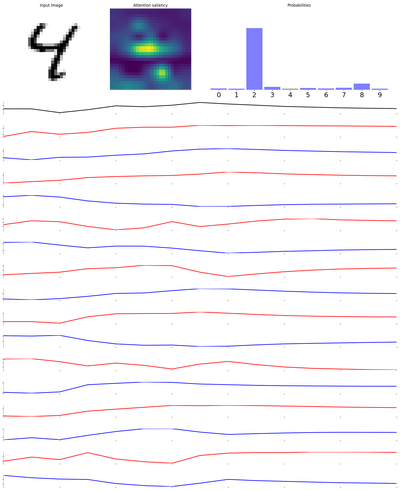

In [12]:
logdir = 'mnist_ctmattention_logs'
os.makedirs(logdir, exist_ok=True)

model.eval()
# NOTE: deliberately NOT using torch.inference_mode() / no_grad here. We need
# a live computational graph so Grad-CAM-style saliency can be computed on
# attention tensors. Keep the visualization batch small to bound memory.
viz_n = 16
inputs, targets = next(iter(testloader))
inputs = inputs[:viz_n].to(device)
targets = targets[:viz_n]

predictions, certainties, attention_tensors, token_activations, _ = model(inputs, track=True)

# --- Grad-CAM-style attention saliency, per outer tick ---------------------
# For each tick t, we backprop the model's predicted-class logit at tick t
# w.r.t. that tick's attention tensor. ReLU(A) * ReLU(grad) keeps only the
# (query, key) pairs that the model both attends to AND uses positively;
B = inputs.size(0)
T = predictions.size(-1)
predicted_classes = predictions.argmax(dim=1).detach()         # (B, T)

saliencies = []
for t in range(T):
    tgt = predictions[torch.arange(B, device=predictions.device),
                      predicted_classes[:, t], t].sum()
    grad_t = torch.autograd.grad(tgt, attention_tensors[t],
                                 retain_graph=(t < T - 1))[0]   # (B, H, L_q, L_kv)
    sal = (attention_tensors[t].clamp(min=0) * grad_t.clamp(min=0))
    # Average over heads, then over queries -> per-key saliency (B, L_kv)
    sal = sal.mean(dim=1).mean(dim=1)
    saliencies.append(sal.detach().cpu())

saliency = torch.stack(saliencies, dim=0)                        # (T, B, L_kv)
grid = int(round(saliency.size(-1) ** 0.5))
saliency = saliency.view(T, B, grid, grid)
heatmap = F.interpolate(saliency, size=(28, 28), mode='bilinear',
                        align_corners=False).numpy()             # (T, B, 28, 28)

make_gif(
    predictions.detach().cpu().numpy(),
    certainties.detach().cpu().numpy(),
    targets.detach().cpu().numpy(),
    token_activations,
    heatmap,
    inputs.detach().cpu().numpy(),
    f'{logdir}/prediction.gif',
)
